In [22]:
def id_to_embed(data:list):
    def process_nested(item):
        if isinstance(item, (list, np.ndarray)):
            return [process_nested(x) for x in item]
        else:
            return np.asarray(nlp(id_to_word[item]).vector)
    
    return process_nested(data)

### Tensor
similar to List but an Object and Helps in Keeping Track. Just similar to torch.Tensor at core

In [23]:
import numpy as np
class Tensor:
    def __init__(self, data, children=(), op='', label=''):
        self.data = np.atleast_2d(np.asarray(data))
        self.label = label
        self.grad = np.asarray(np.zeros(shape=(self.data.shape)))
        #Internal variable for in
        self._op = op
        self._prev = children
        self._backward = lambda:None

    def __repr__(self):
        return f"Tensor :{self.data}"

    def __mul__(self, other):
        try:
            if not isinstance(other, Tensor):
                other = Tensor(other)

            if other.data.shape == (1, 1) and self.data.shape[1] != other.data.shape[0]:
                return self.elementwise_mul(other)


            # print("dims Self",self.data.shape,"dims other: ", (other.data.shape))
            out = Tensor(
                data = np.matmul(self.data, other.data),
                children=(self, other),
                op='*'
            )
            def _backward():
                self.grad += np.matmul(out.grad, other.data.swapaxes(-1, -2))
                other.grad += self.unbroadcast(np.matmul(self.data.swapaxes(-1,-2), out.grad),other.data.shape)

            out._backward = _backward
            return out
        except Exception as e:
            raise ValueError(
                f"Matrix multiplication failed: self dimensions {self.data.shape}, "
                f"other dimensions {other.data.shape}"
            ) from e

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Tensor(np.pow(self.data,other), children=(self,), op=f'**{other}')
        def _backward():
            self.grad += (other * np.pow(self.data,other-1)) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        out = Tensor(np.exp(self.data),children=(self,), op="exp")

        def _backward():
            self.grad += out.data * out.grad  #element wise multiplication
        out._backward = _backward
        return out

    def transpose(self):
        out = Tensor(np.array(self.data).transpose(),op='T',children=(self,))
        def _backward():
            self.grad += out.grad.transpose()
        out._backward = _backward
        return out

    def softmax(self) -> 'Tensor':
        shifted = self.data - np.max(self.data, axis=-1, keepdims=True)
        exp_shifted = np.exp(shifted)
        softmax_data = exp_shifted / np.sum(exp_shifted, axis=-1, keepdims=True)

        out = Tensor(softmax_data, op='softmax', children=(self,))

        def _backward():
            # correct softmax Jacobian, per row:
            # dL/dx_i = s_i * (dL/dout_i - sum_j(s_j * dL/dout_j))
            s = out.data
            dot = np.sum(s * out.grad, axis=-1, keepdims=True)
            self.grad += s * (out.grad - dot)

        out._backward = _backward
        return out

    def relu(self):
        b = self.data
        out = Tensor(np.where(np.greater_equal(0, b), 0, b),children=(self,),label='ReLU')

        def _backward():
            self.grad += (out.data>0)*out.grad

        out._backward = _backward
        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)


        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = np.asarray(np.ones(shape=(self.data.shape)))

        for v in reversed(topo):
            v._backward()

    def __sub__(self, other): # self - other
        return self + (-other)

    def __neg__(self): # -self
        return self * -1

    def __rmul__(self, other): #__rmul__ is used by python when a * b can't be calculated then python tries b * a
        return self*other

    def __radd__(self, other): # other + self
        return self + other

    def cat(tensors:list['Tensor'], axis = -1):
        if not isinstance(tensors, (list, tuple)):
            raise TypeError("cat() expects a list or tuple of Tensor objects")
        if len(tensors) == 0:
            raise ValueError("cat() requires at least one tensor")
        if not all(isinstance(t, Tensor) for t in tensors):
            raise TypeError("All elements in tensors must be Tensor instances")
        if len(tensors)==1: return tensors[0]

        out_data = np.concatenate([t.data for t in tensors],axis=axis)

        out = Tensor(out_data,
           children=tuple(tensors),
            op="cat"
        )
        def _backward():
            start = 0
            for t in tensors:
                size = t.grad.shape[axis]
                end = start + size
                idx = [slice(None)] * out.grad.ndim
                idx[axis] = slice(start,end)
                t.grad += out.grad[tuple(idx)]
                start = end
        out._backward = _backward
        return out

    def unbroadcast(self,grad, shape, label=''):
        # Remove extra dimensions on the left
        while grad.ndim > len(shape):
            grad = np.sum(grad, axis=0)
        # Sum dimensions where original shape was 1
        for axis, size in enumerate(shape):
            if size == 1 and grad.shape[axis] != 1:
                grad = np.sum(grad, axis=axis, keepdims=True)
        return grad

    def __add__(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)
        out = Tensor(np.add(self.data, other.data), children=(self, other), op='+')
        def _backward():
            # print("trying to add: ", other.grad, out.data.shape)
            self.grad += self.unbroadcast(out.grad, self.data.shape)
            other.grad += self.unbroadcast(out.grad, other.data.shape)
        out._backward = _backward

        return out

    def elementwise_mul(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)
        out = Tensor(
            data=self.data * other.data,
            children=(self, other),
            op='ew*'
        )
        def _backward():
            self.grad +=  self.unbroadcast(other.data * out.grad, shape=self.data.shape)
            other.grad += self.unbroadcast(self.data * out.grad, shape=other.data.shape)
        out._backward = _backward
        return out

    def mean(self,axis=1):
        out = Tensor(np.mean(self.data, axis=axis,keepdims=True),children=(self,),op='mean')
        def _backward():
            if axis is None:
                # If mean is taken over all elements, gradient is distributed equally
                self.grad += out.grad / self.data.size
            else:
                # If mean is taken over a specific axis
                self.grad += (1/self.data.shape[axis])*out.grad
        out._backward = _backward
        return out

    def std(self,axis = 1):
        out = Tensor(np.std(self.data,axis=axis,keepdims=True),children=(self,),op='std')
        def _backward():
            self.grad = out.grad * (self.data - np.mean(self.data)) / (self.data.shape[axis] * out.data)
        out._backward = _backward
        return out

    def tanh(self):
        e = self.elementwise_mul(2).exp()
        out = Tensor(
            (e - 1).data * ((e + 1)**-1).data,
            children=(self,),
            op='tanh'
        )

        def _backward():
            self.grad += out.grad * (1 - out.data**2)

        out._backward = _backward
        return out
    def log(self):
        out = Tensor(np.log(self.data), children=(self,), op='log')

        def _backward():
            self.grad += out.grad / self.data

        out._backward = _backward
        return out
    def sum(self, axis=1):
        out = Tensor(np.sum(self.data, axis=axis, keepdims=True,dtype=float), children=(self,), op='sum')
        
        def _backward():
            self.grad += np.ones_like(self.data) * out.grad  # broadcast grad back to original shape
        
        out._backward = _backward
        return out
    
    def pick(self, batch_idx, seq_idx, label_idx):
        # self.data shape: (batch, seq, vocab)
        # batch_idx, seq_idx, label_idx: numpy arrays, shape (batch, seq)
        picked_data = self.data[batch_idx, seq_idx, label_idx]   # shape (batch, seq)

        out = Tensor(picked_data, children=(self,), op='pick')

        def _backward():
            grad = np.zeros_like(self.data)               # (batch, seq, vocab)
            grad[batch_idx, seq_idx, label_idx] = out.grad # scatter grad back to picked positions
            self.grad += grad

        out._backward = _backward
        return out
    def swapaxes(self, axis1, axis2):
        out = Tensor(
            np.swapaxes(self.data, axis1, axis2),
            children=(self,),
            op='swapaxes'
        )

        def _backward():
            self.grad += np.swapaxes(out.grad, axis1, axis2)

        out._backward = _backward
        return out

### Graphvis for visualisation

In [24]:
%%script false --no-raise-error

!pip install graphviz
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    def matrix_html(matrix):
        matrix = np.atleast_2d(matrix)
        rows = []
        for row in matrix:
            cells = ''.join(
                f'<TD BORDER="1" CELLPADDING="4">{value:.4g}</TD>'
                for value in row
            )
            rows.append(f'<TR>{cells}</TR>')
        return (
            '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">'
            + ''.join(rows) +
            '</TABLE>'
        )

    for n in nodes:
        label = (
            f'<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0">'
            f'<TR><TD><B>{n.label}</B></TD></TR>'
            f'<TR><TD>{matrix_html(n.data)}</TD></TR>'
            f'<TR><TD>grad</TD></TR>'
            f'<TR><TD>{matrix_html(n.grad)}</TD></TR>'
            f'</TABLE>>'
        )

        dot.node(
            name=str(id(n)),
            label=label,
            shape='plain'
        )

        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

def draw_graph(end_targate):
    end_targate.backward()
    dot = draw_dot(end_targate)
    dot.body[:] = [
        line.replace("<B></B>", "<B>&#160;</B>")
        for line in dot.body
    ]
    dot.render()
    display(dot)


### Multi layer perceptron
created Neuron --> Layer --> MLP

In [25]:
from typing import Literal
import random
import warnings

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = np.zeros_like(p.data)

    def parameters(self):
        return []


class Neuron(Module):
    def __init__(self, m_features, non_linear=True,activation_fn: Literal["tanh", "relu"] = "relu"):
        std = np.sqrt(2 / m_features)       
        self.W = Tensor(np.random.randn(m_features,1) * std,label="w")
        self.b = Tensor([[0.0]],label="bias")

        self.non_linear = non_linear
        self.activation_fn = activation_fn

    def __call__(self, x):

        # print("lr:", lr)
        # print("W:", self.W.data.min(), self.W.data.max())
        # print("grad:", self.W.grad.min(), self.W.grad.max())
        # x is expected to be:
        # (batch_size, m_features)
        x = Tensor(np.asarray(x, dtype=float)) if not isinstance(x, Tensor) else x

        # for matmul (x,W) == (n_inp, p_words, m_features),(m_features,1) --> (n_inp,p_words,1)
        
        # print(((x.data.shape),self.W.data.shape))
        act = ( x * self.W ) + self.b

        # Return matmul shape: (n_inp, p_words, 1)
        # Final layer: return raw logits
        if not self.non_linear:
            return act

        # Hidden layer activation
        activation = getattr(act, self.activation_fn)()
        return activation

    def parameters(self):
        return [self.W, self.b]

    def __repr__(self):
        activation = self.activation_fn if self.non_linear else "linear"
        return f"{activation} Neuron({self.W.data.shape[1]})"


class Layer(Module):
    def __init__(self,layer_id,m_features,n_out,activation_fn="relu",non_linear=True):
        self.layer_id = layer_id
        self.non_linear = non_linear
        self.neurons = [Neuron(m_features=m_features,activation_fn=activation_fn,non_linear=non_linear) for _ in range(n_out)]

    def __call__(self, x):
        # Each neuron produces:(n_inp,p_words,1) * L neuron .Cat --> (n_inp,p_words, L )
        outputs = [neuron(x) for neuron in self.neurons]
        outputs:Tensor = Tensor.cat(outputs, axis=-1)
        # print("input", outputs)
        if not self.non_linear:
            if outputs.data.shape[-1] > 1:
                outputs = outputs.softmax()
                # print("output", outputs)
        # print(f"Layer id: {self.layer_id},outputs.data.min(),outputs.data.max()")
        return outputs

    def parameters(self):
        return [ p for neuron in self.neurons for p in neuron.parameters()]

    def __repr__(self):
        return (f"Layer of " f"[{', '.join(str(n) for n in self.neurons)}]")


class MLP(Module):

    def __init__( self, m_features: int, Layer_outs: list[int], activation_fn="relu",loss_type: Literal["mse", "cross_entropy"] = "mse"):
        input_size = [m_features] + Layer_outs
        self.loss_type = loss_type
        self.layers = [
            Layer(
                layer_id=i,
                m_features=input_size[i],
                n_out=input_size[i + 1],

                # Hidden layers -> activation
                # Final layer -> linear
                non_linear=(i != len(Layer_outs) - 1),
                activation_fn=activation_fn
            )
            for i in range(len(Layer_outs))
        ]

    def predict(self, x):
        # Convert input to Tensor once
        if not isinstance(x, Tensor):
            x = Tensor(np.asarray(x, dtype=float))

        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [ p for layer in self.layers for p in layer.parameters()]

    def Fit( self, x, y, epoch=200, lr=0.0001, batch_size=32):
        n = len(x)
        epoch_loss_history = []

        for _ in range(epoch):

            # Shuffle every epoch
            indices = list(range(n))
            random.shuffle(indices)

            epoch_loss = 0.0
            num_batches = 0

            for current_batch in range(0, n, batch_size):

                batch_indices = indices[current_batch:current_batch + batch_size]
                # x_batch = [id_to_embed(x[i]) for i in batch_indices]
                x_batch = [id_to_embed(x[i]) for i in batch_indices]
                y_batch = [y[i] for i in batch_indices]
                # Forward pass
                ypred = self.predict(x_batch)
               
                # print(f"Epoch: {epoch_no}, batch Numer: {current_batch}: yprediction: {ypred.data.min,ypred.data.max}", )
                # Convert target to Tensor
                y_batch = (
                    y_batch
                    if isinstance(y_batch, Tensor)
                    else Tensor(np.asarray(y_batch, dtype=float), label="Output")
                )

                # Check shape
                if y_batch.data.shape != ypred.data.shape and self.loss_type =='mse':
                    raise ValueError(
                        "Prediction and target shape mismatch: "
                        f"y.shape={y_batch.data.shape}, "
                        f"ypred.shape={ypred.data.shape}"
                    )

                # Forward + backward + update
                loss = self._GradientDescent(
                    y=y_batch, ## Lables [-100,id,-100,---]
                    ypred=ypred, 
                    lr=lr,
                    loss_type=self.loss_type
                )
                # Store scalar loss
                epoch_loss += float(np.asarray(loss.data).mean())
                num_batches += 1

            # Average batch losses
            
            epoch_loss_history.append(epoch_loss / num_batches)
        print(epoch_loss_history)
        return epoch_loss_history

    def _GradientDescent(self,y, ypred, loss_type, lr=0.1):

        # Co  nvert y to Tensor
        if not isinstance(y, Tensor):
            y = Tensor(
                np.asarray(y, dtype=float),
                label="Output"
            )

        # Reset gradients
        for p in self.parameters():
            p.grad = np.zeros_like(p.data)

        # Calculate loss
        loss:Tensor = self._Calculate_Loss(
            ypred=ypred, 
            y=y,  ## Lables [-100,id,-100,---]
            loss_type=loss_type,
        )

        # Backprop
        loss.backward()
        # print("lossB", loss.grad)
        
        # Gradient descent
        for p in self.parameters():
            p.data -= lr * p.grad

        return loss

    def _Calculate_Loss(self,ypred: Tensor, y: Tensor, loss_type,):
        # y: Labels = [-100,-100,...id...]
        # ypred: vocab probs 
        # x: Actaul Ids with masked

        if loss_type == "mse":

            # Element-wise squared error
            squared_error = (ypred - y) ** 2
            # print(ypred)
            # Mean over all elements
            return squared_error.mean()

        elif loss_type == "cross_entropy":
            safe_labels = np.where(np.asarray(y.data) == -100, 0, np.asarray(y.data)).astype(int)
            batch_size, seq_len, vocab_size = ypred.data.shape
            assert vocab_size == len(vocabulary), f"vocab_size mismatch: got {vocab_size}, expected {len(vocabulary)}"

            batch_idx = np.arange(batch_size)[:, None] * np.ones((1, seq_len), dtype=int)
            seq_idx = np.arange(seq_len)[None, :] * np.ones((batch_size, 1), dtype=int)
            mask = Tensor((np.asarray(y.data) != -100).astype(float))  # (batch, seq)
            number_of_valid = mask.sum()

            eps = Tensor([[1e-7]])
            safe_ypred = ypred + eps
            picked = safe_ypred.pick(batch_idx, seq_idx, safe_labels)  # (batch, seq)

            log_probs = picked.log()                                   # (batch, seq) -- already per-word, no sum needed
            masked_loss = log_probs.elementwise_mul(mask)               # (batch, seq)
            loss = masked_loss.sum().elementwise_mul(-1.0).elementwise_mul(number_of_valid ** -1)
            return loss
        else:
            raise ValueError(
                f"Unknown loss type: {loss_type}"
            )
            
    def __repr__(self):
        return (
            f"MLP of "
            f"[{', '.join(str(layer) for layer in self.layers)}]"
        )
        


In [26]:
# #Sanity Test for multi dims
# word_embeds =[
#     [[0.6972834, 0.08725786, -0.1506938, -0.67638519],[-1.30838017, -1.7098192, -1.44106524, -1.63344123]],
#     [[0.6972834, 0.08725786, -0.1506938, -0.67638519],[-1.30838017, -1.7098192, -1.44106524, -1.63344123]],
#     [[0.6972834, 0.08725786, -0.1506938, -0.67638519],[-1.30838017, -1.7098192, -1.44106524, -1.63344123]],
#     ]
# #word_embeds_shape = [3,3,3]
# word_embeds_id = [
#   [[-0.04213773], [-6.09270584]],
#   [[-0.04213773], [-6.09270584]],
#   [[-0.04213773], [-6.09270584]],
# ]

# model  = MLP(m_features=np.shape(word_embeds)[-1], Layer_outs=[32,32,1],activation_fn='relu',loss_type='mse')
# loss = model.Fit(word_embeds,word_embeds_id,epoch=10,batch_size = 1,lr=0.001)
# import matplotlib.pyplot as plt
# plt.plot(loss)

### Transformer

In [27]:
import numpy as np
# from .backprop import Tensor

def sinusoidal_positional_encoding(p_words:int, m_features:int):
    #n_sentences, p_words, m_features = embedding dims of each word are m_feature
    #P_E(pos,2i) = sin(pos/10000^(2i/n_dims))
    #P_E(pos,2i+1) = cos(pos/10000^(2i/n_dims))

    #division term = position/10000^(2i/n_dims) = position * 10000^-(2i/n_dims) = position * e^(-2*position*log(10000)/n_dims)
    position = np.arange(p_words)[:,np.newaxis]
    div_term = np.exp(-2*position*np.log(10000)/m_features)

    pos_embed = np.zeros(shape=(p_words,m_features))
    #even position 
    pos_embed[:,0::2] = np.sin(position*div_term)
    pos_embed[:,1::2] = np.cos(position*div_term)
    pos_embed = Tensor(pos_embed,label='pos_embed')
    return pos_embed

class attention_head:
    def __init__(self, shape: tuple[int, int] = (1, 1)):
        self.m, self.n = shape
        std = np.sqrt(2 / self.m)  
        self.W_q = Tensor(np.random.randn(self.n,self.n)*std,label='w_q')
        self.W_k = Tensor(np.random.randn(self.n,self.n)*std,label='w_k')
        self.W_v = Tensor(np.random.randn(self.n,self.n)*std,label='w_v')

    def __call__(self, pos_aware_embed:Tensor):
        # """Attention"""
        Q = pos_aware_embed * self.W_q
        K = pos_aware_embed * self.W_k
        V = pos_aware_embed * self.W_v
        div_factor = Tensor(1/np.sqrt(self.n))
        similarity = div_factor.elementwise_mul(Q * K.swapaxes(-1,-2)) 
        attn_weights = similarity.softmax()  # normalize scores across key positions
        context_embed = attn_weights * V     # then weight the values
        return context_embed
    def perameter(self):
        return self.W_q,self.W_k,self.W_v


class Transformer(MLP):
    def __init__(self, n_heads:int = 8, ):
        self.n_heads = n_heads #number of attention head
        self.lr = 0.01
        # """ FFN Model """
        self.model = MLP(m_features=96, Layer_outs=[32,32,len(word_to_id)],activation_fn='relu',loss_type='cross_entropy')
        
    def _encoder(self,X):
        if not isinstance(X,Tensor):
            X = Tensor(X)
        self.X = X
        # self.X = Tensor(X,label='Data ingestion') #[n_sentences, p_words, m_features]
        n = len(X.data)
        indices = list(range(n))
        random.shuffle(indices)
        
        # print("Data Ingestion Successfull, Shape: ", X)
        n_sentences, p_words, m_features = np.shape(X.data)
        std = np.sqrt(2 / m_features)       
        self.all_attention_heads = [attention_head(shape=(p_words,m_features)) for _ in range(self.n_heads)]
        self.W_multi_head = Tensor(np.random.randn(m_features * self.n_heads, m_features) * std,label="multihead")
        
        P_E:Tensor = sinusoidal_positional_encoding(p_words, m_features)
        pos_aware_embed = self.X.__add__(P_E)  #pos_aware_embed = positional encoding

        # Multi head attention

        tensors = [head(pos_aware_embed) for head in self.all_attention_heads]
        multi_head_attention:Tensor = Tensor.cat(tensors) * self.W_multi_head
        add:Tensor = multi_head_attention + pos_aware_embed
        
        
        # add:Tensor = add + (add.mean().elementwise_mul(-1)) 
        # add_n_norm:Tensor = add.elementwise_mul(add.std()**-1); add_n_norm.label = 'add n norm'
        eps = 1e-5
        
        mean = add.mean(axis=-1)      # per-token mean, not global
        var = ((add + mean.elementwise_mul(-1)) ** 2).mean(axis=-1)
        std = (var + eps) ** 0.5                      # eps prevents divide-by-zero

        centered = add + mean.elementwise_mul(-1)
        add_n_norm = centered.elementwise_mul(std ** -1)
        
        return add_n_norm

    def Fit(self,X:list,Y:list,epoch=5,batch_size = 1,lr=0.1,loss_type='cross_entropy'):
        n = len(x)
        epoch_loss_history = []

        for _ in range(epoch):

            # Shuffle every epoch
            indices = list(range(n))
            random.shuffle(indices)

            epoch_loss = 0.0
            num_batches = 0

            for current_batch in range(0, n, batch_size):

                batch_indices = indices[current_batch:current_batch + batch_size]
                # x_batch = [id_to_embed(x[i]) for i in batch_indices]
                x_batch = [id_to_embed(X[i]) for i in batch_indices] 
                y_batch = [Y[i] for i in batch_indices]

                
                # print(f"Epoch: {epoch_no}, batch Numer: {current_batch}: yprediction: {ypred.data.min,ypred.data.max}", )
                # Convert target to Tensor
                y_batch = (
                    y_batch
                    if isinstance(y_batch, Tensor)
                    else Tensor(np.asarray(y_batch, dtype=float), label="Output")
                )
                
                # Forward pass
                pos_aware_embed = self._encoder(x_batch)
                ypred = self.model.predict(pos_aware_embed)

                # Check shape
                if y_batch.data.shape != ypred.data.shape and loss_type =='mse':
                    raise ValueError(
                        "Prediction and target shape mismatch: "
                        f"y.shape={y_batch.data.shape}, "
                        f"ypred.shape={ypred.data.shape}"
                    )

                # Forward + backward + update
                loss = self._GradientDescent(
                    y=y_batch, ## Lables [-100,id,-100,---]
                    ypred=ypred, 
                    lr=lr,
                    loss_type=loss_type
                )
                # Store scalar loss
                epoch_loss += float(np.asarray(loss.data).mean())
                num_batches += 1

            # Average batch losses
            
            epoch_loss_history.append(epoch_loss / num_batches)
        print(epoch_loss_history)
        return epoch_loss_history, loss
    

    def parameters(self):
        params = [self.W_multi_head]
        for head in self.all_attention_heads:
            params.extend(head.perameter())
        params.extend(self.model.parameters())
        return params
    
    

# Data Prep

In [28]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt

In [29]:
#Read csv-------------------
# %%script false --no-raise-error
df = pd.read_csv('../database/shortdb.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


#### Preprocessing

In [30]:
# %%script false --no-raise-error

print(df.info())
print("Target data distribution: ",[int((i/37249)*100) for i in df.category.value_counts()])


df.dropna(inplace=True)
print("Total null Values: ",df.isnull().sum())
#lower casing
df['clean_comment'] = df['clean_comment'].str.lower()

#remove punctuation
import string
exclude = string.punctuation
print(exclude)
def removepunc(text:str):
    return text.translate(str.maketrans('','',exclude))

df['clean_comment'] = df['clean_comment'].apply(removepunc)
df.head()

#stop word removal
# !pip install nltk
import nltk
from nltk.corpus import stopwords
import time
# nltk.download('stopwords')
en_stopwords = stopwords.words('english')

def removestopwords(text:str):
    newword = []
    for word in text.split():
        if word not in en_stopwords:
            newword.append(word)
    x = newword[:]
    newword.clear()
    return " ".join(x)

df['clean_comment'] = df.clean_comment.apply(removestopwords)

#emoji replacement with their meaning
# !pip install emoji
import emoji
df.clean_comment = df.clean_comment.apply(emoji.demojize)


#Nltk not that accurate but for now, just use it
from nltk.tokenize import word_tokenize
# nltk.download('punkt_tab')
df.clean_comment = df.clean_comment.apply(word_tokenize)
df.head()

from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
def stem_word(text_row):
    return (" ".join(ps.stem(word) for word in text_row))
df.clean_comment = df.clean_comment.apply(stem_word)
df['split_comment'] = df.clean_comment.str.split()

df.head(1)



<class 'pandas.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   clean_comment  286 non-null    str  
 1   category       286 non-null    int64
dtypes: int64(1), str(1)
memory usage: 4.6 KB
None
Target data distribution:  [0, 0, 0]
Total null Values:  clean_comment    0
category         0
dtype: int64
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


,clean_comment,category,split_comment
0,famili mormon never tri explain still stare pu...,1,"[famili, mormon, never, tri, explain, still, s..."


#### Vocab Preparing for bert like Model Training

In [31]:
# %%script false --no-raise-error
unique_words = set()
for comment_words in df['split_comment']:
    unique_words.update(comment_words)

vocabulary = ['[PAD]', '[CLS]','[UNK]', '[SEP]', '[MASK]'] + list(unique_words)
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}
id_to_word = {idx: word for idx, word in enumerate(vocabulary)}


df['split_comment'] = df['split_comment'].apply(lambda x: [word_to_id[i] for i in x])
df['split_comment'] = df['split_comment'].apply(
    lambda x: [word_to_id['[CLS]']] + x[:62] +
              [word_to_id['[SEP]']] +
              [word_to_id['[PAD]']] * (62 - len(x[:62]))
)
# Display a sample of the created word_to_id mapping and its size
print(f"Vocabulary size: {word_to_id}")
print(f"Vocabulary size: {id_to_word}")
df.head()


Vocabulary size: {'[PAD]': 0, '[CLS]': 1, '[UNK]': 2, '[SEP]': 3, '[MASK]': 4, 'pictur': 5, 'html': 6, 'fetter': 7, 'lich': 8, 'uplift': 9, 'mainstream': 10, 'statur': 11, 'demograph': 12, 'arnab': 13, 'tyranni': 14, '6000': 15, '2nd': 16, 'learn': 17, 'parekh': 18, 'mm': 19, 'lost': 20, 'temporari': 21, 'beauti': 22, 'crime': 23, 'loot': 24, 'mibe': 25, 'palpabl': 26, 'break': 27, 'lifetim': 28, 'veg': 29, 'version': 30, 'young': 31, 'juli': 32, 'laps': 33, 'robberi': 34, 'minor': 35, 'base': 36, 'fare': 37, 'handl': 38, 'jenkinson': 39, 'includ': 40, 'zealalem': 41, 'na': 42, 'yashwant': 43, '10pm': 44, 'second': 45, 'bewild': 46, 'silent': 47, 'pre': 48, 'argu': 49, 'addict': 50, 'blood': 51, 'throught': 52, 'mee': 53, 'brand': 54, 'rajiv': 55, 'incept': 56, 'somewhat': 57, 'rofl': 58, 'borrow': 59, 'discoveri': 60, 'regardless': 61, 'contest': 62, 'supapowaaa': 63, 'known': 64, 'properli': 65, 'moron': 66, 'clinic': 67, 'slide': 68, 'distinctli': 69, 'newer': 70, 'nachn': 71, 'touc

,clean_comment,category,split_comment
0,famili mormon never tri explain still stare pu...,1,"[1, 1874, 1164, 827, 632, 1940, 1078, 464, 623..."
1,buddhism much lot compat christian especi cons...,1,"[1, 1047, 1270, 1399, 656, 1321, 1806, 2151, 9..."
2,serious say thing first get complex explain no...,-1,"[1, 967, 2283, 1031, 675, 574, 546, 1940, 1439..."
3,learn want teach differ focu goal wrap paper b...,0,"[1, 17, 1520, 1232, 891, 1463, 1144, 403, 330,..."
4,benefit may want read live buddha live christ ...,1,"[1, 1708, 1285, 1520, 1145, 1410, 1312, 1410, ..."


### Sentence to Vector

### Masking + Length Equilizing

In [32]:
# %%script false --no-raise-error
import random

def mask_input_rows(sentence_vec: list, mask_prob=0.15):

    labels = [-100] * len(sentence_vec)  # if its not -100 get the -log(prediction) if the prediction is lower --> high loss else low loss

    for index in range(1, len(sentence_vec) - 1):  # skip CLS (0) and SEP (last)
        if random.random() < mask_prob:
            
            labels[index] = sentence_vec[index]  # store original id as label

            r = random.random()
            if r < 0.8:
                sentence_vec[index] = word_to_id['[MASK]']
            elif r < 0.9:
                sentence_vec[index] = random.randint(0, len(word_to_id) - 1)
            # else: leave unchanged (10%), label still set above

    return labels 

df['labels']=df['split_comment'].apply(mask_input_rows)
df.head(1)


,clean_comment,category,split_comment,labels
0,famili mormon never tri explain still stare pu...,1,"[1, 1874, 1164, 827, 632, 1940, 1078, 464, 623...","[-100, -100, -100, -100, -100, -100, -100, -10..."


In [33]:
# %%script false --no-raise-error
from sklearn.model_selection import train_test_split
x = df['split_comment']
y = df['labels']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


print(x_train.shape)
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)



(228,)
x_train: (228,)
x_test: (58,)
y_train: (228,)
y_test: (58,)


# Train

In [34]:
#Gensim Library implementation of Word2Vec
import subprocess
import sys
import spacy
from spacy.util import is_package

MODEL = "en_core_web_sm"

if not is_package(MODEL):
    subprocess.check_call([
        sys.executable, "-m", "spacy", "download", MODEL
    ])

nlp = spacy.load(MODEL,disable=["tagger", "parser", "ner", "lemmatizer"])


In [35]:
x = np.stack(np.asarray(x_train[:10]))
y = np.stack(np.asarray(y_train[:10]))
np.shape(x),np.shape(y)

((10, 64), (10, 64))

In [36]:
np.shape(x),np.shape(y)

((10, 64), (10, 64))

In [37]:
# trans = Transformer()
# model = MLP(m_features=96, Layer_outs=[32,32,len(word_to_id)],activation_fn='relu')

In [38]:
# loss = model.Fit(x,y,epoch=10,batch_size = 1,lr=0.1,loss_type='cross_entropy')
# import matplotlib.pyplot as plt
# plt.plot(loss)



In [39]:
# model.parameters()

# Transformer

[6.511210373046365, 2.7861278799032343, 2.7861278798084754, 2.786128335804155, 2.786119662581023, 2.7861278798085207, 2.7861278798085136, 2.786127879808599, 2.786127879808514, 2.7861273961314788]


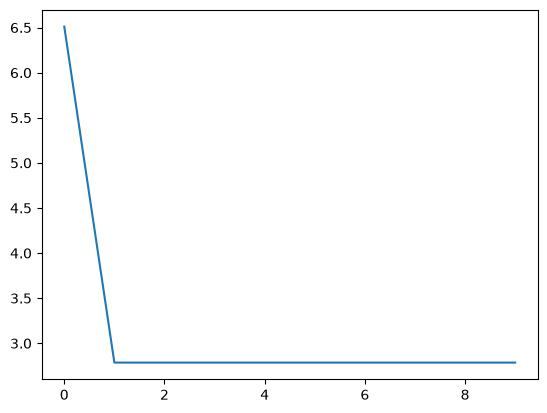

In [ ]:
trans = Transformer()
lossHistory = trans.Fit(x,y,epoch=10,batch_size=5,lr=0.5)
import matplotlib.pyplot as plt
plt.plot(lossHistory[0])


In [41]:
[i.grad for i in trans.parameters()]

[array([[-1.01164175e-15,  1.27524641e-14,  5.95917126e-15, ...,
         -1.51963225e-15, -1.07524155e-14,  1.09601545e-14],
        [-7.26066583e-16,  1.89457210e-15,  8.57127221e-16, ...,
         -9.60514233e-16, -6.07529395e-16,  8.22418734e-16],
        [ 2.91675498e-16,  6.12909686e-15,  2.90158671e-15, ...,
          2.61785226e-16, -6.50279461e-15,  6.35374331e-15],
        ...,
        [-7.74811371e-16,  1.18577150e-14,  5.54812122e-15, ...,
         -1.20217856e-15, -1.02793572e-14,  1.04193371e-14],
        [-1.22937042e-15,  1.51759082e-15,  6.56204329e-16, ...,
         -1.59493060e-15,  6.21955263e-16, -2.42382588e-16],
        [ 6.25362504e-16, -2.87555407e-15, -1.32443815e-15, ...,
          8.49446776e-16,  1.74227485e-15, -1.91618674e-15]],
       shape=(768, 96)),
 array([[ 2.20715637e-16,  4.12488356e-15,  1.74665407e-15, ...,
          2.40063608e-15, -1.21800754e-14, -4.26595084e-15],
        [ 4.59310436e-17,  1.40355313e-15,  6.90742576e-16, ...,
          8.79